Dataset: UAC_Forecasting_Project\data\processed_data.csv
Training: 576
Testing : 144
✅ SARIMA model fitted
Forecast generated: 144

SARIMA RESULTS
Model: SARIMA(1,1,1)x(1,1,1,7)
MAE : 691.64
RMSE: 907.97
MAPE: 30.21%


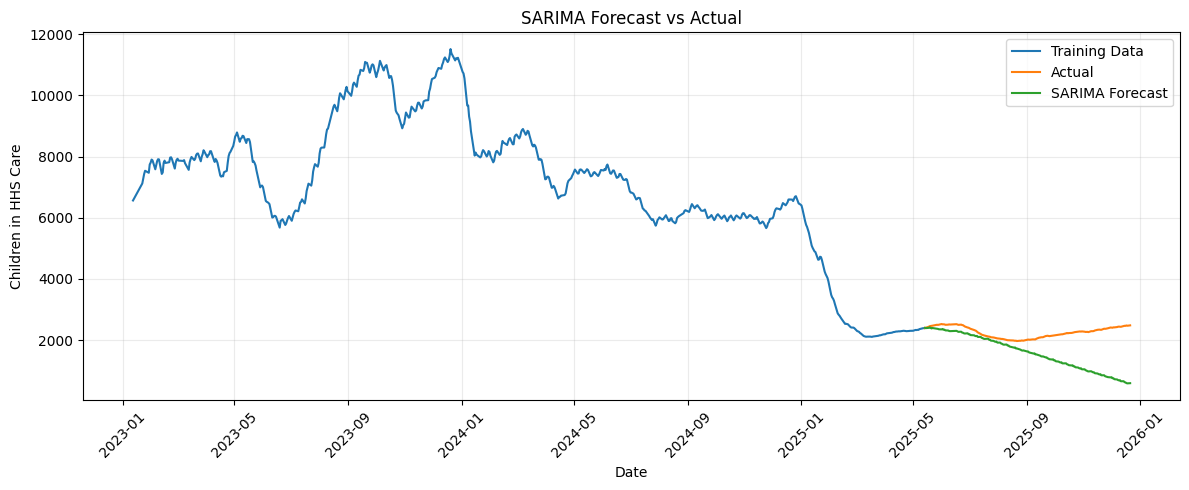


✅ Predictions saved:
C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\sarima_predictions.csv

✅ Metrics saved:
C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\sarima_metrics.csv


In [2]:
# ==========================================
# SARIMA - COMPLETE SELF-CONTAINED CELL
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ------------------------------------------
# 1. Find dataset
# ------------------------------------------

data_candidates = [
    Path("data/processed_data.csv"),
    Path("UAC_Forecasting_Project/data/processed_data.csv")
]

data_path = next(
    (p for p in data_candidates if p.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        f"processed_data.csv not found.\n"
        f"Current directory: {Path.cwd()}"
    )

print("Dataset:", data_path)


# ------------------------------------------
# 2. Load data
# ------------------------------------------

df = pd.read_csv(data_path)

target = "Children in HHS Care"

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df[target] = (
    df[target]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df[target] = pd.to_numeric(
    df[target],
    errors="coerce"
)

df = df.dropna(
    subset=["Date", target]
)

df = df.sort_values("Date")

# One value per date
df = (
    df.groupby("Date")[target]
    .mean()
    .to_frame()
)

series = df[target].astype(float)

series = series.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()


# ------------------------------------------
# 3. Train / Test split
# ------------------------------------------

split_index = int(
    len(series) * 0.80
)

train = series.iloc[:split_index]
test = series.iloc[split_index:]

print("Training:", len(train))
print("Testing :", len(test))


# ------------------------------------------
# 4. Fit SARIMA
# ------------------------------------------

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(
    disp=False
)

print("✅ SARIMA model fitted")


# ------------------------------------------
# 5. Forecast
# ------------------------------------------

forecast = fit.forecast(
    steps=len(test)
)

forecast = pd.Series(
    np.asarray(forecast, dtype=float),
    index=test.index
)

print("Forecast generated:", len(forecast))


# ------------------------------------------
# 6. Evaluation
# ------------------------------------------

evaluation = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast.values
})

evaluation = evaluation.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

if evaluation.empty:
    raise ValueError(
        "SARIMA produced no valid forecast values."
    )

actual = evaluation["Actual"]
predicted = evaluation["Forecast"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

nonzero = actual != 0

if nonzero.any():
    mape = (
        np.mean(
            np.abs(
                (actual[nonzero] - predicted[nonzero])
                / actual[nonzero]
            )
        ) * 100
    )
else:
    mape = np.nan


# ------------------------------------------
# 7. Results
# ------------------------------------------

print("\n" + "=" * 45)
print("SARIMA RESULTS")
print("=" * 45)

print("Model: SARIMA(1,1,1)x(1,1,1,7)")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

print("=" * 45)


# ------------------------------------------
# 8. Plot
# ------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    forecast.values,
    label="SARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.title("SARIMA Forecast vs Actual")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


# ------------------------------------------
# 9. Save results
# ------------------------------------------

output_candidates = [
    Path("data"),
    Path("UAC_Forecasting_Project/data")
]

output_dir = next(
    (p for p in output_candidates if p.exists()),
    None
)

if output_dir is None:
    raise FileNotFoundError(
        "Project data folder not found."
    )

predictions = pd.DataFrame({
    "Date": test.index,
    "Actual": test.values,
    "SARIMA Forecast": forecast.values
})

predictions_path = (
    output_dir / "sarima_predictions.csv"
)

predictions.to_csv(
    predictions_path,
    index=False
)

metrics = pd.DataFrame([{
    "Model": "SARIMA(1,1,1)x(1,1,1,7)",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape
}])

metrics_path = (
    output_dir / "sarima_metrics.csv"
)

metrics.to_csv(
    metrics_path,
    index=False
)

print("\n✅ Predictions saved:")
print(predictions_path.resolve())

print("\n✅ Metrics saved:")
print(metrics_path.resolve())